# Growth from Single Disk
First simulation after refactoring.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import (
    make_lattice,
    make_birth_kernel,
    ModelConfig,
    NoAdhesion,
    HardThresholdModifier,
    PowerLawModifier,
    BoltzmannModifier,
    CultureSimulator,
)

from lib import (
    result_to_frame,
    aggregate_results,
    fit_power_law_exponent,
    plot_observables,
    plot_ensemble_curve,
    plot_snapshots,
)

## Birth only

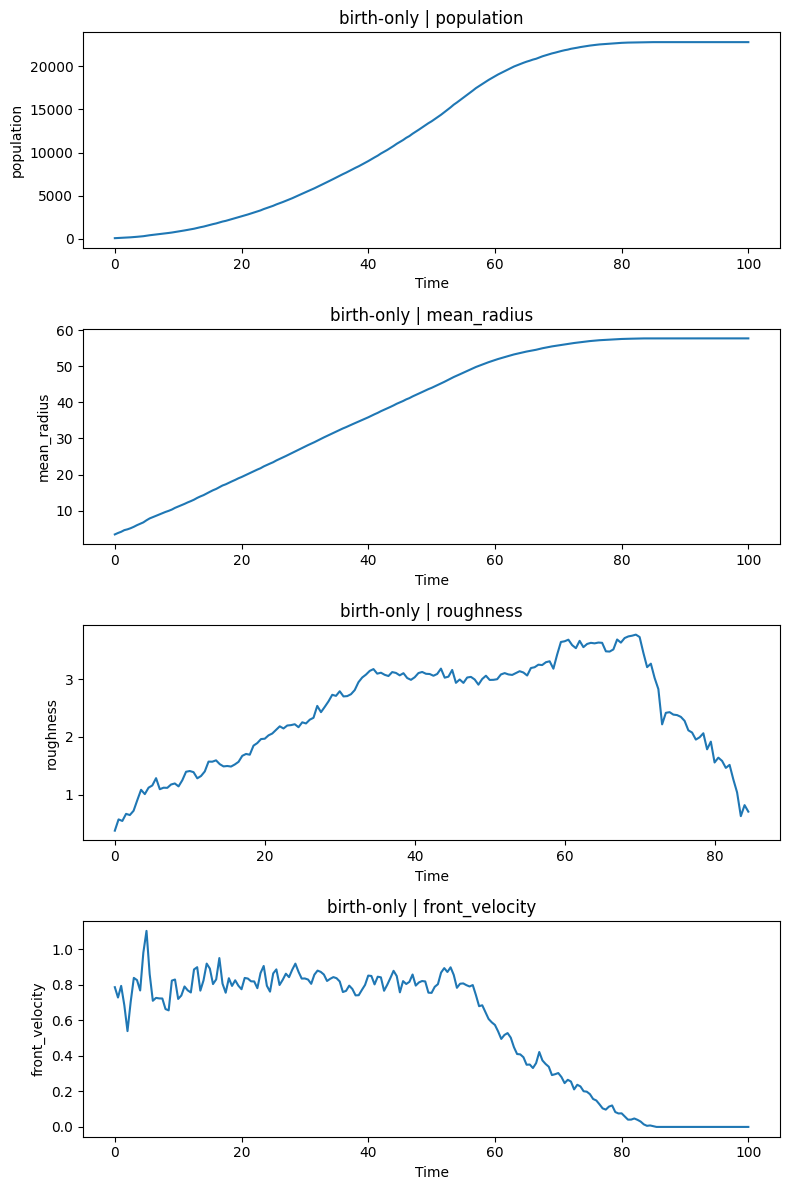

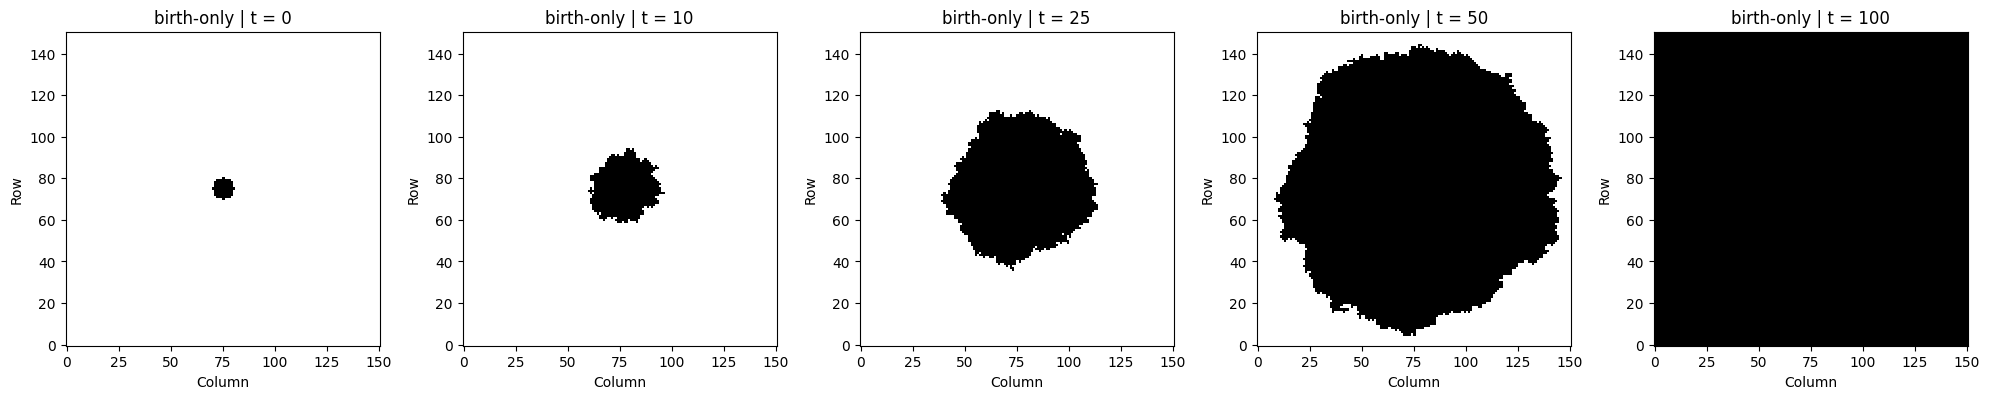

In [2]:
# ----------------------------
# Geometry and initialization
# ----------------------------
lattice = make_lattice(kind="square", nrows=151, ncols=151, periodic=False)
initial_state = lattice.make_disk_state(radius=5.0)

# ----------------------------
# Model configuration
# ----------------------------
config = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),
    r_birth=1.0,
    r_death=0.0,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

# ----------------------------
# Simulation
# ----------------------------
simulator = CultureSimulator(lattice=lattice)

t_final = 100.0
observation_times = np.linspace(0.0, t_final, 201)

result = simulator.run(
    initial_state=initial_state,
    config=config,
    t_final=t_final,
    rng=np.random.default_rng(12345),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_observables(result, title_prefix="birth-only | ")
plot_snapshots(lattice, result, times_to_show=[0.0, 10.0, 25.0, 50.0, 100.0], title_prefix="birth-only | ")

## Front-growth exponent

In [3]:
fit_radius = fit_power_law_exponent(
    times=result.times,
    values=result.mean_radius,
    t_min=5.0,
    t_max=60.0,
)

fit_roughness = fit_power_law_exponent(
    times=result.times,
    values=result.roughness,
    t_min=5.0,
    t_max=70.0,
)

print("Mean-radius exponent fit:")
print(fit_radius)

print("\nRoughness exponent fit:")
print(fit_roughness)

Mean-radius exponent fit:
{'alpha': 0.8371956765915541, 'log_C': 0.4917492985765681, 'C': 1.635174127333333, 'r2_loglog': 0.9957389545665077, 'n_points': 111}

Roughness exponent fit:
{'alpha': 0.5202172022615866, 'log_C': -0.864972815571912, 'C': 0.4210629988285534, 'r2_loglog': 0.9504888298212969, 'n_points': 131}


## Birth-death

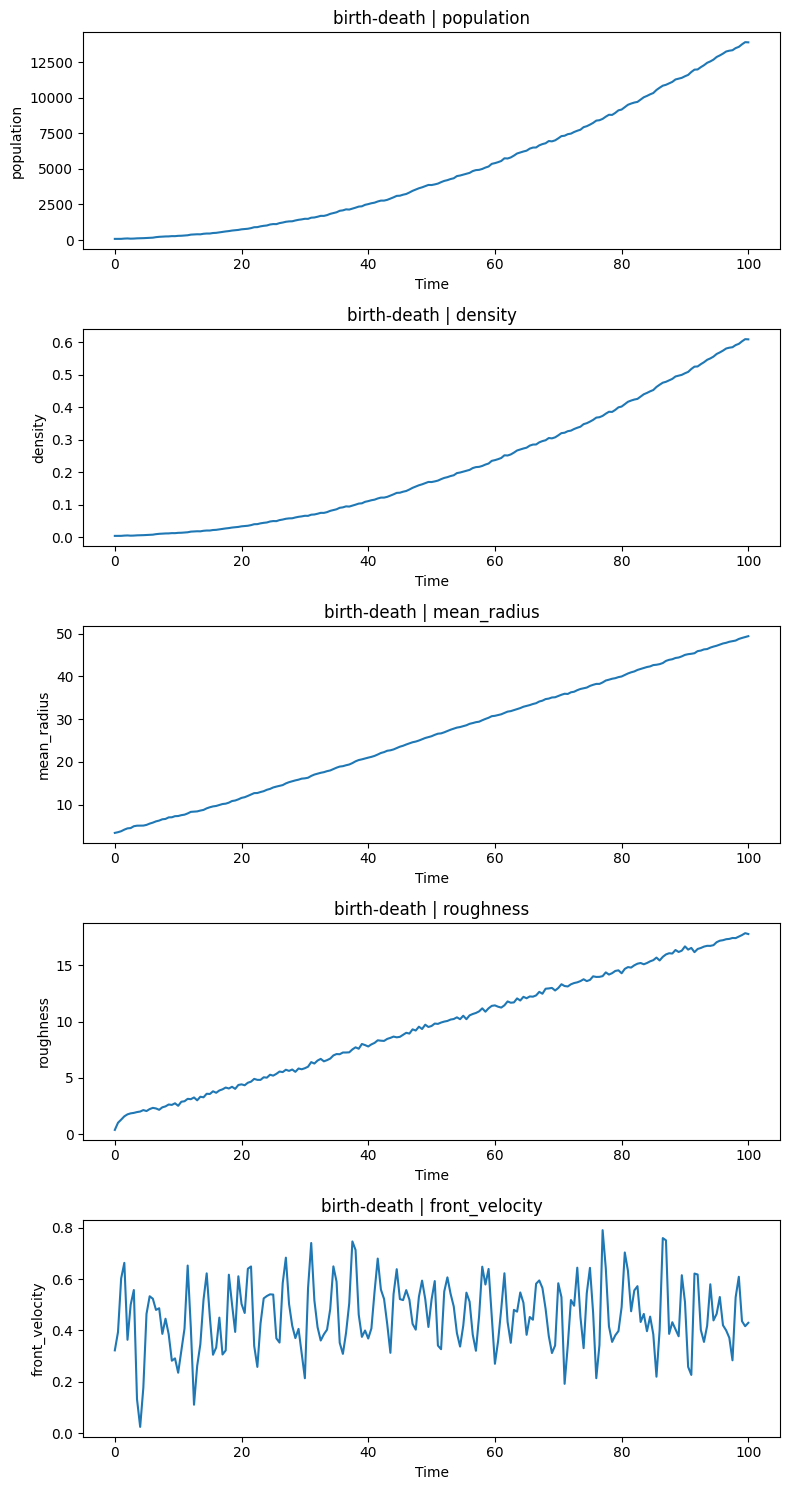

In [4]:
gamma = 2.0
r_birth = 1.0
r_death = r_birth / gamma

config_bd = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),  # empty_driven
    r_birth=r_birth,
    r_death=r_death,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

result_bd = simulator.run(
    initial_state=initial_state,
    config=config_bd,
    t_final=100.0,
    rng=np.random.default_rng(2026),
    observation_times=observation_times,
    store_snapshots=False,
)

plot_observables(
    result_bd,
    which=("population", "density", "mean_radius", "roughness", "front_velocity"),
    title_prefix="birth-death | ",
)

Let's do a power-law fit.

In [7]:
# Fit power-law exponents for birth-death case
# Choose the observable and fitting window
observable_name = "population"   # try also: "mean_radius", "roughness"
t_min = 5.0
t_max = 80.0

values = getattr(result_bd, observable_name)

fit = fit_power_law_exponent(
    times=result_bd.times,
    values=values,
    t_min=t_min,
    t_max=t_max,
)

print(f"Observable: {observable_name}")
print(f"Fit window: [{t_min}, {t_max}]")
print(f"alpha = {fit['alpha']:.6f}")
print(f"C = {fit['C']:.6f}")
print(f"R^2 (log-log) = {fit['r2_loglog']:.6f}")
print(f"n_points = {fit['n_points']}")

Observable: population
Fit window: [5.0, 80.0]
alpha = 1.626942
C = 6.591925
R^2 (log-log) = 0.989162
n_points = 151


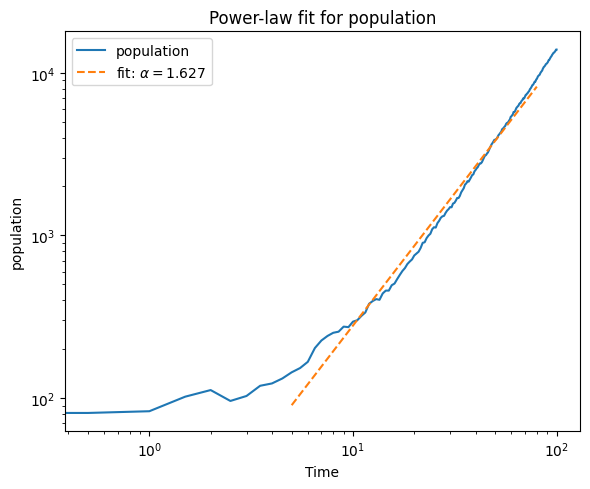

In [8]:
# Plot the data and the fit
observable_name = "population"   # same choice as above
t_min = 5.0
t_max = 80.0

values = getattr(result_bd, observable_name)

mask = (
    np.isfinite(result_bd.times)
    & np.isfinite(values)
    & (result_bd.times > 0.0)
    & (values > 0.0)
    & (result_bd.times >= t_min)
    & (result_bd.times <= t_max)
)

t_fit = result_bd.times[mask]
y_fit = values[mask]

fit = fit_power_law_exponent(
    times=result_bd.times,
    values=values,
    t_min=t_min,
    t_max=t_max,
)

y_model = fit["C"] * t_fit ** fit["alpha"]

plt.figure(figsize=(6, 5))
plt.loglog(result_bd.times, values, label=observable_name)
plt.loglog(t_fit, y_model, "--", label=fr"fit: $\alpha={fit['alpha']:.3f}$")
plt.xlabel("Time")
plt.ylabel(observable_name)
plt.title(f"Power-law fit for {observable_name}")
plt.legend()
plt.tight_layout()
plt.show()

Let's try a linear fit.

In [9]:
observables = ["population", "mean_radius", "roughness"]

# Choose the fitting window
t_min = 5.0
t_max = 80.0

fit_results = {}

for obs_name in observables:
    y = getattr(result_bd, obs_name)
    t = result_bd.times

    mask = (
        np.isfinite(t)
        & np.isfinite(y)
        & (t >= t_min)
        & (t <= t_max)
    )

    t_fit = t[mask]
    y_fit = y[mask]

    if t_fit.size < 2:
        print(f"{obs_name}: not enough valid points for fitting.")
        continue

    slope, intercept = np.polyfit(t_fit, y_fit, deg=1)
    y_pred = slope * t_fit + intercept

    ss_res = np.sum((y_fit - y_pred) ** 2)
    ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    fit_results[obs_name] = {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "t_fit": t_fit,
        "y_fit": y_fit,
        "y_pred": y_pred,
    }

    print(f"{obs_name}")
    print(f"  slope     = {slope:.6f}")
    print(f"  intercept = {intercept:.6f}")
    print(f"  R^2       = {r2:.6f}")
    print()

population
  slope     = 121.511684
  intercept = -1706.067741
  R^2       = 0.957721

mean_radius
  slope     = 0.471825
  intercept = 2.335174
  R^2       = 0.999497

roughness
  slope     = 0.170769
  intercept = 1.042191
  R^2       = 0.998627



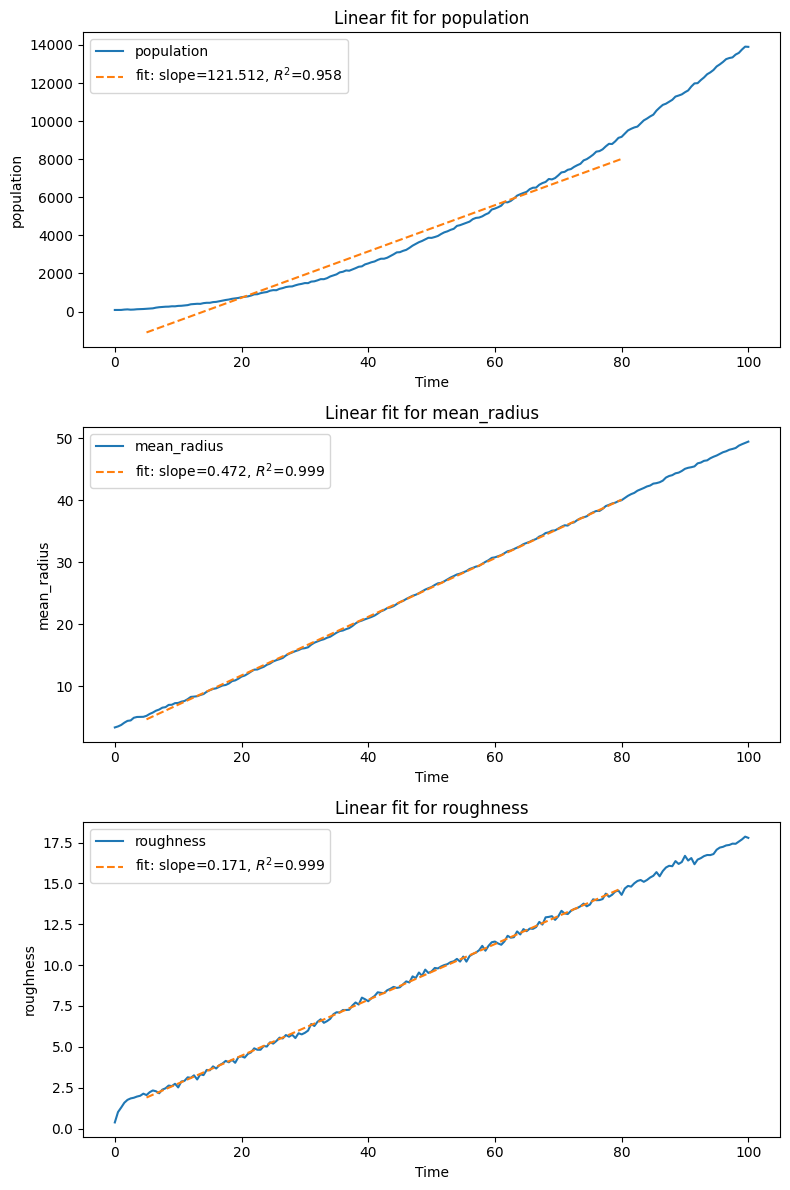

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12), squeeze=False)

for ax, obs_name in zip(axes[:, 0], observables):
    y = getattr(result_bd, obs_name)
    t = result_bd.times

    ax.plot(t, y, label=obs_name)

    if obs_name in fit_results:
        t_fit = fit_results[obs_name]["t_fit"]
        y_pred = fit_results[obs_name]["y_pred"]
        slope = fit_results[obs_name]["slope"]
        r2 = fit_results[obs_name]["r2"]

        ax.plot(
            t_fit,
            y_pred,
            "--",
            label=fr"fit: slope={slope:.3f}, $R^2$={r2:.3f}",
        )

    ax.set_xlabel("Time")
    ax.set_ylabel(obs_name)
    ax.set_title(f"Linear fit for {obs_name}")
    ax.legend()

plt.tight_layout()
plt.show()

Let's do a quadratic fit for population over time.

In [15]:
# Choose fitting window
t_min = 5.0
t_max = 90.0

t = result_bd.times
y = result_bd.population

mask = (
    np.isfinite(t)
    & np.isfinite(y)
    & (t >= t_min)
    & (t <= t_max)
)

t_fit = t[mask]
y_fit = y[mask]

# Quadratic fit
a, b, c = np.polyfit(t_fit, y_fit, deg=2)

y_pred = a * t_fit**2 + b * t_fit + c

# R^2
ss_res = np.sum((y_fit - y_pred) ** 2)
ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

print("Quadratic fit for population")
print(f"  a (t^2) = {a:.6e}")
print(f"  b (t)   = {b:.6e}")
print(f"  c       = {c:.6e}")
print(f"  R^2     = {r2:.6f}")

Quadratic fit for population
  a (t^2) = 1.315628e+00
  b (t)   = 9.801579e+00
  c       = 4.156825e+01
  R^2     = 0.999787


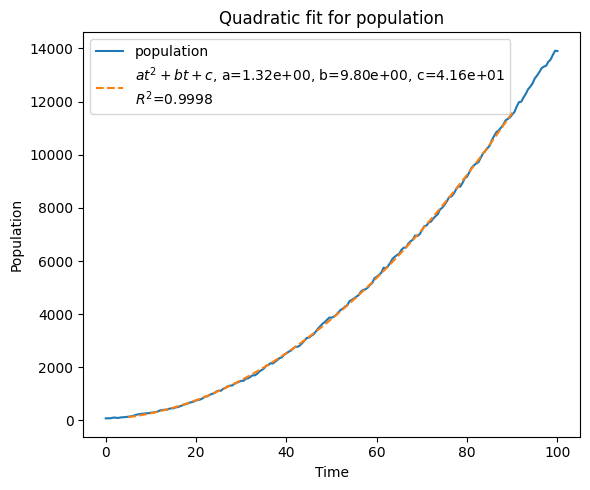

In [18]:
plt.figure(figsize=(6, 5))

plt.plot(t, y, label="population")

plt.plot(
    t_fit,
    y_pred,
    "--",
    label=fr"$at^2+bt+c$, a={a:.2e}, b={b:.2e}, c={c:.2e}" + "\n" + fr"$R^2$={r2:.4f}",
)

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Quadratic fit for population")
plt.legend()
plt.tight_layout()
plt.show()

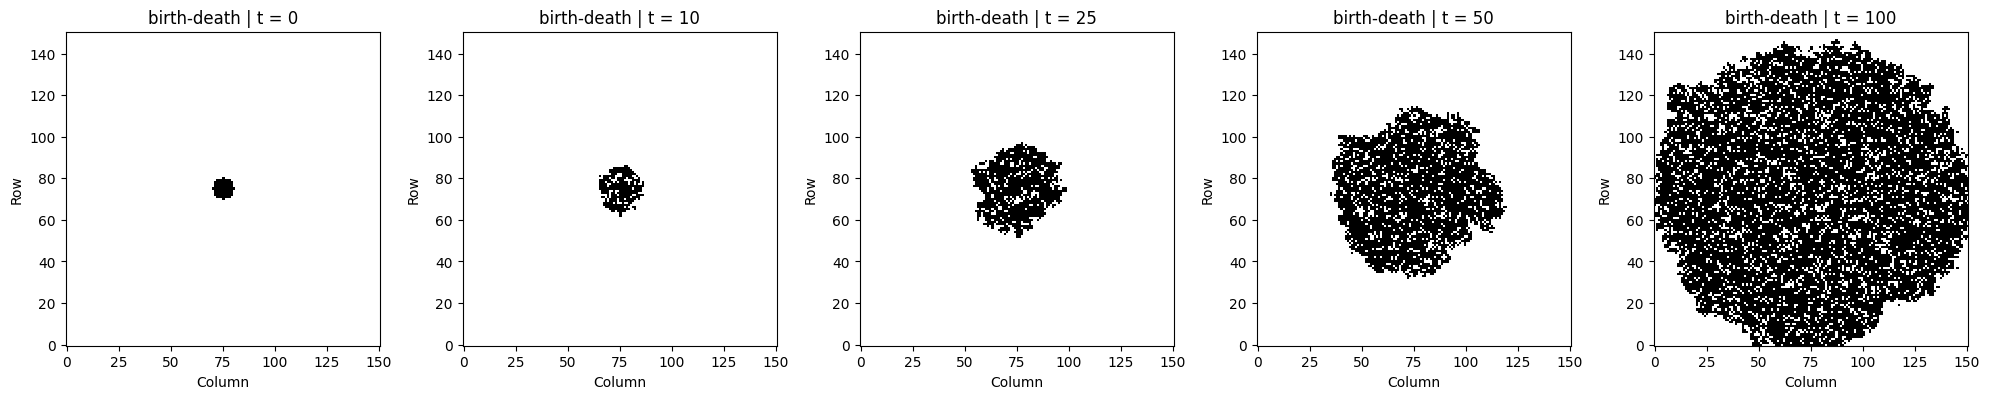

In [19]:
snapshot_times = [0.0, 10.0, 25.0, 50.0, 100.0]

result_bd_snap = simulator.run(
    initial_state=initial_state,
    config=config_bd,
    t_final=100.0,
    rng=np.random.default_rng(2026),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_snapshots(
    lattice=lattice,
    result=result_bd_snap,
    times_to_show=snapshot_times,
    title_prefix="birth-death | ",
)

In [22]:
# ========= Density ========
# Fit window
t_min = 5.0
t_max = 90.0

t = result_bd.times
y = result_bd.density

mask = (
    np.isfinite(t)
    & np.isfinite(y)
    & (t >= t_min)
    & (t <= t_max)
)

t_fit = t[mask]
y_fit = y[mask]

# Quadratic fit
a, b, c = np.polyfit(t_fit, y_fit, deg=2)

y_pred = a * t_fit**2 + b * t_fit + c

# R^2
ss_res = np.sum((y_fit - y_pred) ** 2)
ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

print("Quadratic fit for density")
print(f"  a (t^2) = {a:.6e}")
print(f"  b (t)   = {b:.6e}")
print(f"  c       = {c:.6e}")
print(f"  R^2     = {r2:.6f}")

Quadratic fit for density
  a (t^2) = 5.770044e-05
  b (t)   = 4.298750e-04
  c       = 1.823089e-03
  R^2     = 0.999787


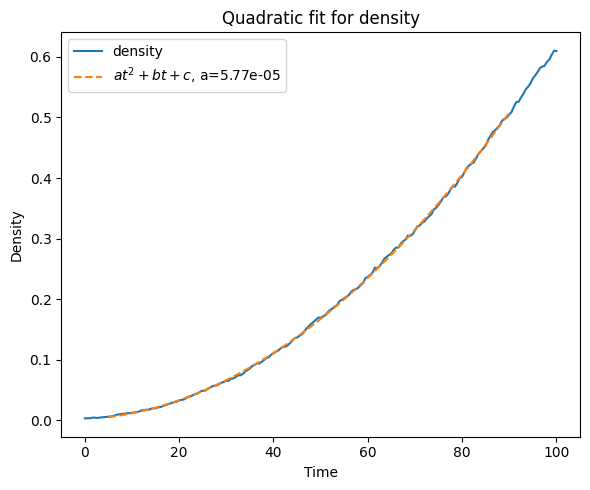

In [23]:
plt.figure(figsize=(6, 5))

plt.plot(t, y, label="density")
plt.plot(
    t_fit,
    y_pred,
    "--",
    label=fr"$at^2+bt+c$, a={a:.2e}",
)

plt.xlabel("Time")
plt.ylabel("Density")
plt.title("Quadratic fit for density")
plt.legend()
plt.tight_layout()
plt.show()

Does front velocity have a characteristic wave length / frequency?

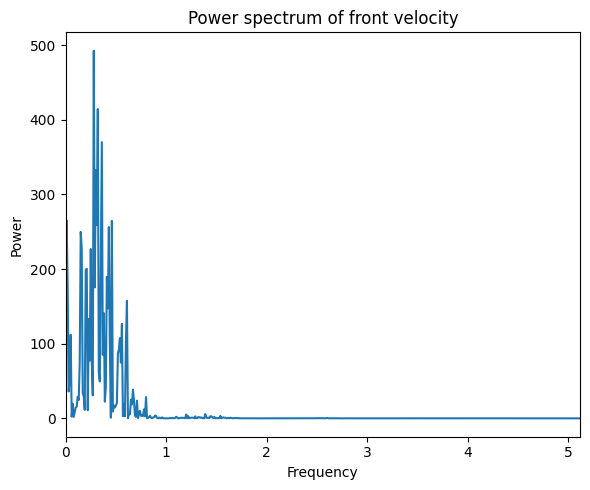

In [24]:
from scipy.interpolate import interp1d

t = result_bd.times
v = result_bd.front_velocity

# Remove NaNs
mask = np.isfinite(t) & np.isfinite(v)
t = t[mask]
v = v[mask]

# Uniform grid
n_uniform = 1024
t_uniform = np.linspace(t.min(), t.max(), n_uniform)

interp = interp1d(t, v, kind="linear", fill_value="extrapolate")
v_uniform = interp(t_uniform)

v_centered = v_uniform - np.mean(v_uniform)

fft_vals = np.fft.rfft(v_centered)
freqs = np.fft.rfftfreq(n_uniform, d=(t_uniform[1] - t_uniform[0]))

power = np.abs(fft_vals)**2

plt.figure(figsize=(6, 5))

plt.plot(freqs, power)
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.title("Power spectrum of front velocity")
plt.xlim(0, freqs.max())

plt.tight_layout()
plt.show()

In [25]:
# Ignore zero frequency (mean)
idx_peak = np.argmax(power[1:]) + 1

f_peak = freqs[idx_peak]
T_peak = 1.0 / f_peak if f_peak > 0 else np.inf

print(f"Dominant frequency: {f_peak:.6f}")
print(f"Characteristic period: {T_peak:.6f}")

Dominant frequency: 0.279727
Characteristic period: 3.574920


Change `observation_times = np.linspace(0, 100, 2000)` to get a denser sampling. If the dominant frequency changes, it's an artifact.

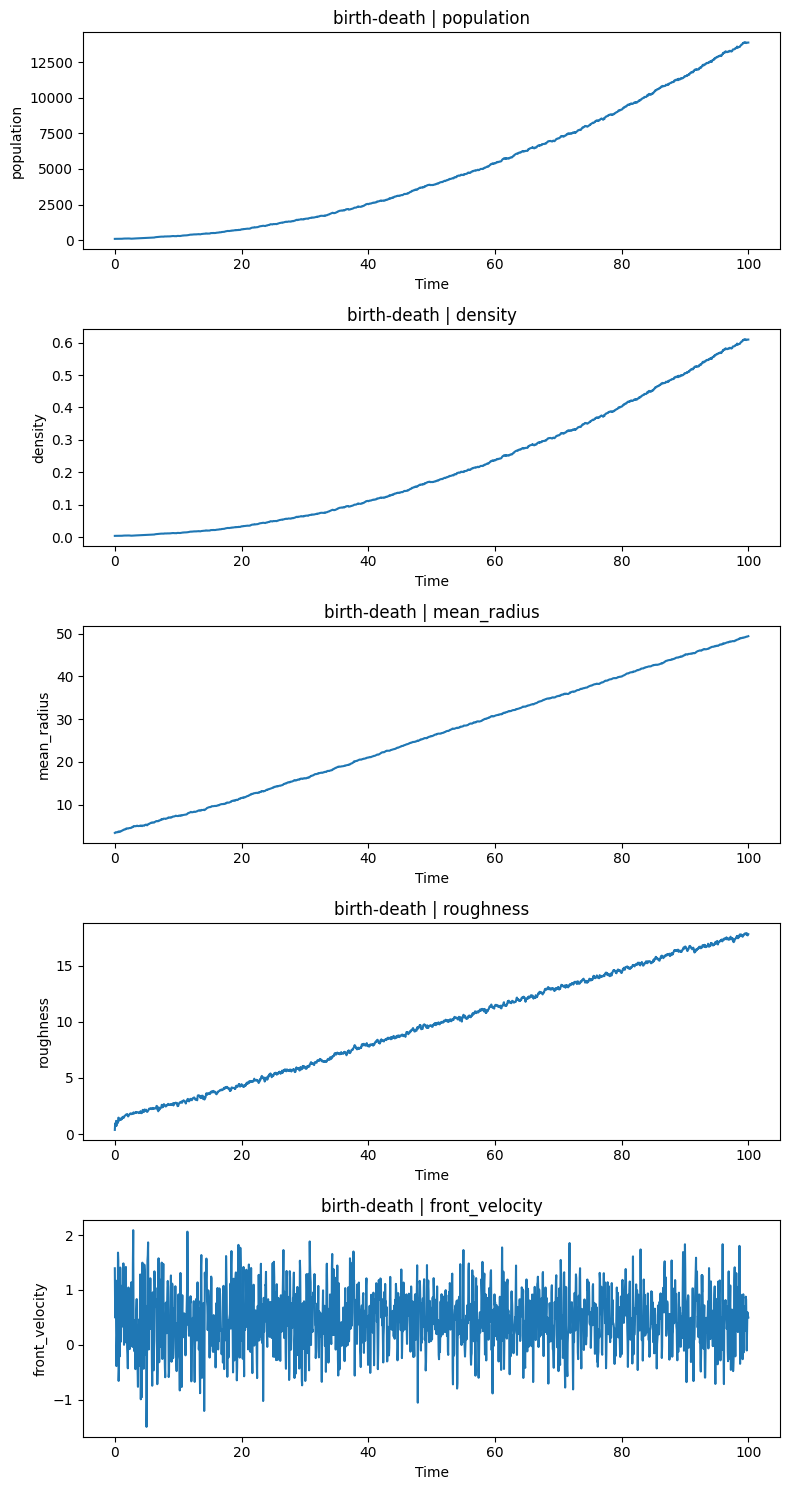

In [26]:
gamma = 2.0
r_birth = 1.0
r_death = r_birth / gamma

observation_times = np.linspace(0, 100, 2000)  # denser

config_bd = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),  # empty_driven
    r_birth=r_birth,
    r_death=r_death,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

result_bd = simulator.run(
    initial_state=initial_state,
    config=config_bd,
    t_final=100.0,
    rng=np.random.default_rng(2026),
    observation_times=observation_times,
    store_snapshots=False,
)

plot_observables(
    result_bd,
    which=("population", "density", "mean_radius", "roughness", "front_velocity"),
    title_prefix="birth-death | ",
)

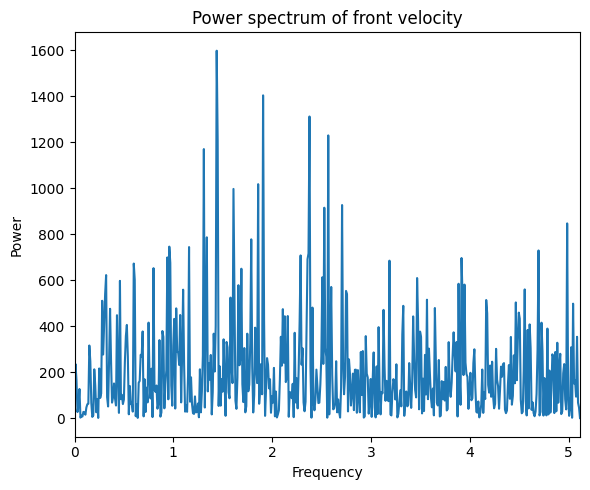

In [27]:
from scipy.interpolate import interp1d

t = result_bd.times
v = result_bd.front_velocity

# Remove NaNs
mask = np.isfinite(t) & np.isfinite(v)
t = t[mask]
v = v[mask]

# Uniform grid
n_uniform = 1024
t_uniform = np.linspace(t.min(), t.max(), n_uniform)

interp = interp1d(t, v, kind="linear", fill_value="extrapolate")
v_uniform = interp(t_uniform)

v_centered = v_uniform - np.mean(v_uniform)

fft_vals = np.fft.rfft(v_centered)
freqs = np.fft.rfftfreq(n_uniform, d=(t_uniform[1] - t_uniform[0]))

power = np.abs(fft_vals)**2

plt.figure(figsize=(6, 5))

plt.plot(freqs, power)
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.title("Power spectrum of front velocity")
plt.xlim(0, freqs.max())

plt.tight_layout()
plt.show()

In [28]:
# Ignore zero frequency (mean)
idx_peak = np.argmax(power[1:]) + 1

f_peak = freqs[idx_peak]
T_peak = 1.0 / f_peak if f_peak > 0 else np.inf

print(f"Dominant frequency: {f_peak:.6f}")
print(f"Characteristic period: {T_peak:.6f}")

Dominant frequency: 1.438594
Characteristic period: 0.695123


In [29]:
np.mean(v_uniform)

np.float64(0.4604736197793619)

This is the same mean as before. There's no oscilation frequency.

#### TL;DR
- population and density are quadratic in time
- mean radius and roughness are linear in time
- tumor is porous
- Front velocity is centered around 0.46, and fluctuates around that value (without actually oscilating)

## Adhesion example on births only

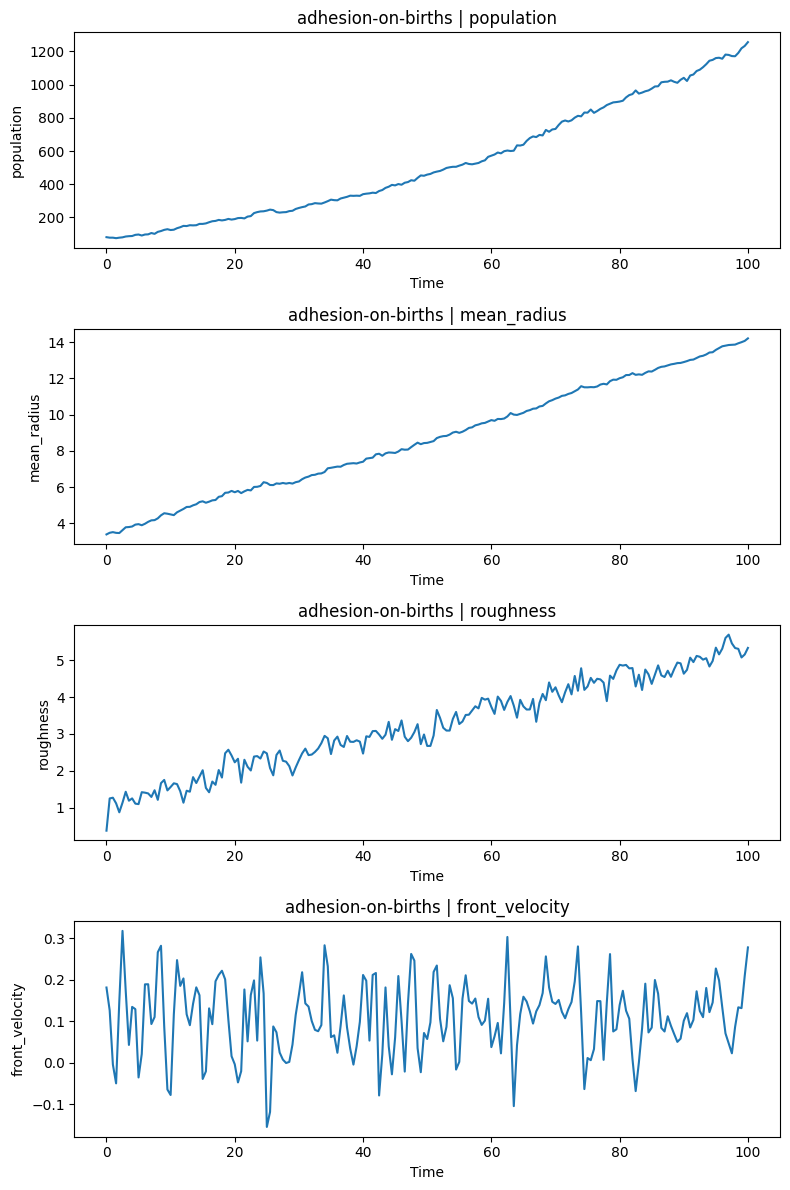

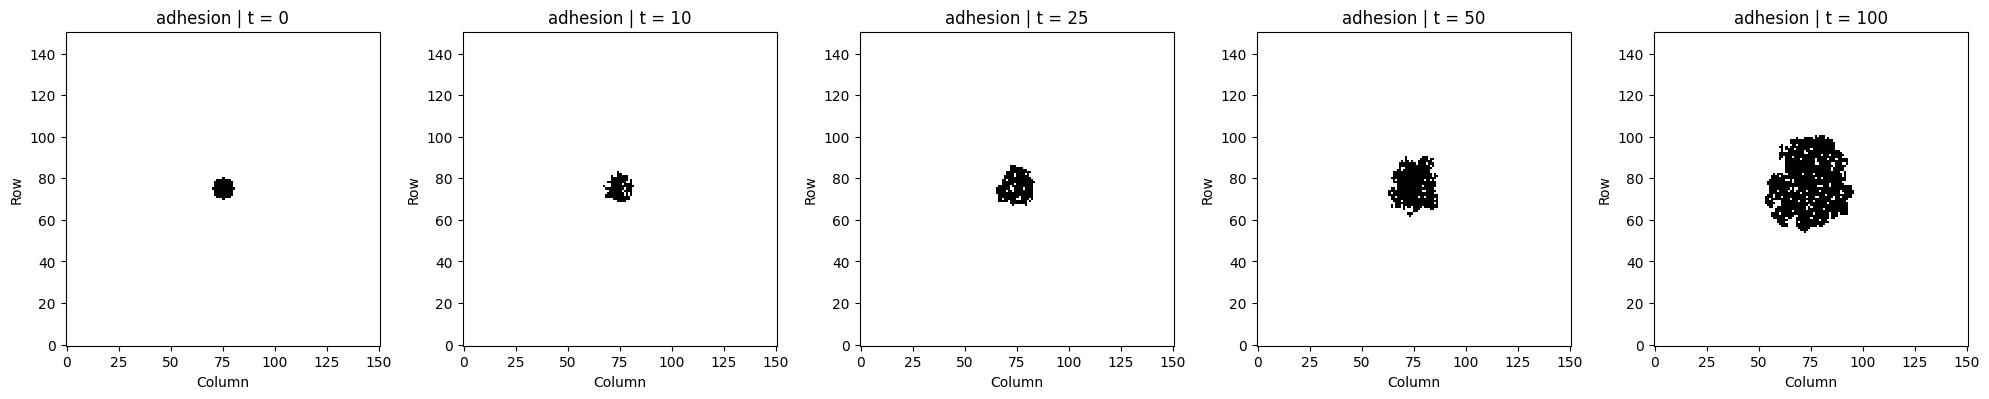

In [31]:
observation_times = np.linspace(0.0, t_final, 201)

config_adh = ModelConfig(
    birth_kernel=make_birth_kernel("empty_driven"),
    r_birth=1.0,
    r_death=0.2,
    birth_modifier=BoltzmannModifier(beta=0.8),   # try also PowerLawModifier(alpha=2.0)
    death_modifier=NoAdhesion(),
)

result_adh = simulator.run(
    initial_state=initial_state,
    config=config_adh,
    t_final=100.0,
    rng=np.random.default_rng(31415),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_observables(result_adh, title_prefix="adhesion-on-births | ")
plot_snapshots(lattice, result_adh, times_to_show=[0.0, 10.0, 25.0, 50.0, 100.0], title_prefix="adhesion | ")

## Ensemble helper for experiment 2

In [ ]:
def run_ensemble(
    lattice_kind: str,
    update_source: str,
    r_birth: float,
    r_death: float,
    birth_modifier,
    death_modifier,
    nrows: int,
    ncols: int,
    seed_radius: float,
    t_final: float,
    n_runs: int,
    base_seed: int,
):
    lattice = make_lattice(kind=lattice_kind, nrows=nrows, ncols=ncols, periodic=False)
    simulator = CultureSimulator(lattice=lattice)
    initial_state = lattice.make_disk_state(radius=seed_radius)
    observation_times = np.linspace(0.0, t_final, 201)

    results = []
    for i in range(n_runs):
        config = ModelConfig(
            birth_kernel=make_birth_kernel(update_source),
            r_birth=r_birth,
            r_death=r_death,
            birth_modifier=birth_modifier,
            death_modifier=death_modifier,
        )

        rng = np.random.default_rng(base_seed + i)

        result = simulator.run(
            initial_state=initial_state,
            config=config,
            t_final=t_final,
            rng=rng,
            observation_times=observation_times,
            store_snapshots=False,
        )
        results.append(result)

    return lattice, results

## Ensemble aggregation example

In [ ]:
lattice, results = run_ensemble(
    lattice_kind="square",
    update_source="cell_driven",
    r_birth=1.0,
    r_death=0.5,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
    nrows=151,
    ncols=151,
    seed_radius=5.0,
    t_final=100.0,
    n_runs=20,
    base_seed=1000,
)

agg = aggregate_results(results)

plot_ensemble_curve(
    agg_df=agg,
    y="mean_population",
    y_std="std_population",
    title="Mean population",
)

plot_ensemble_curve(
    agg_df=agg,
    y="survival_probability",
    title="Survival probability",
)

plot_ensemble_curve(
    agg_df=agg,
    y="mean_density",
    y_std="std_density",
    title="Mean density",
)

## 